<a href="https://colab.research.google.com/github/jermeyjohnson31-lab/Data_analytics/blob/main/Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Citi Bike User Behavior Analysis

**Dataset:** February 2024 Citi Bike Trip Data  
**Objective:** Analyze behavioral differences between members and casual riders across weekdays and weekends.

##  Research Question

How do Citi Bike usage patterns differ between members and casual riders across weekdays and weekends, and what does this reveal about commuting vs leisure behavior?

Step 1: Download Dataset (Safer Version)

---



In [2]:
import requests

url = "https://s3.amazonaws.com/tripdata/202402-citibike-tripdata.zip"

response = requests.get(url, stream=True)

with open("citibike_feb.zip", "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("Download complete.")

Download complete.


Step 2: Extract ZIP

In [3]:
import zipfile

with zipfile.ZipFile("citibike_feb.zip", 'r') as zip_ref:
    zip_ref.extractall("citibike_data")

print("Extraction complete.")

Extraction complete.


Step 3: Check Files Inside

In [4]:
import os

files = os.listdir("citibike_data")
print(files[:5])

['202402-citibike-tripdata_2.csv', '202402-citibike-tripdata_3.csv', '202402-citibike-tripdata_1.csv']


Step 4: Load and combine Dataset Safely

In [5]:
import pandas as pd

csv_files = [f for f in files if f.endswith(".csv")]

df_list = []

for csv_file in csv_files:
  temp_df = pd.read_csv(f"citibike_data/{csv_file}")
  df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
df.head()

/tmp/ipykernel_3270/1606409796.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(f"citibike_data/{csv_file}")
/tmp/ipykernel_3270/1606409796.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(f"citibike_data/{csv_file}")
/tmp/ipykernel_3270/1606409796.py:8: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(f"citibike_data/{csv_file}")


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,DD5AF6C22AA0E39D,electric_bike,2024-02-02 09:03:19.508,2024-02-02 09:06:50.573,E 141 St & St Ann's Ave,7722.06,Westchester Ave & Jackson Ave,7853.01,40.808633,-73.916124,40.816124,-73.908116,member
1,EA8A043F462B5EE1,electric_bike,2024-02-07 17:45:27.103,2024-02-07 17:51:32.029,31 St & Northern Blvd,6495.17,43 Ave & 47 St,6209.05,40.751870,-73.933493,40.744806,-73.917290,member
2,353BB6B40DC6DA15,electric_bike,2024-02-13 16:10:24.042,2024-02-13 16:17:31.047,Melrose Ave & E 150 St,7879.01,E 170 St & Webster Ave,8156.03,40.816827,-73.917338,40.836179,-73.907301,member
3,2E5FBD9C635D6349,electric_bike,2024-02-12 08:53:18.669,2024-02-12 09:09:24.171,11 Ave & W 41 St,6726.01,River Ter & Warren St,5368.03,40.760301,-73.998842,40.717599,-74.015880,member
4,428768F09B80D52B,electric_bike,2024-02-01 19:03:33.564,2024-02-01 19:09:18.077,Washington Park,4546.05,Willoughby St & Fleet St,4628.05,40.691782,-73.973730,40.691966,-73.981302,member


Step 5: Convert Time Columns + Feature Engineering

In [6]:
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])

In [7]:
df["hour"] = df["started_at"].dt.hour
df["day_of_week"] = df["started_at"].dt.day_name()

df["trip_duration_min"] = (
    (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60
)

Step 6: Data Cleaning Step

In [8]:
## Data Cleaning
df_clean = df.copy()

# Remove missing timestamps
df_clean = df_clean.dropna(subset=["started_at", "ended_at"])

# Recompute duration (ensures accuracy)
df_clean["trip_duration_min"] = (
    (df_clean["ended_at"] - df_clean["started_at"]).dt.total_seconds() / 60
)

# Remove invalid trips
df_clean = df_clean[df_clean["trip_duration_min"] > 0]

# Remove extreme outliers (99th percentile method)
upper_limit = df_clean["trip_duration_min"].quantile(0.99)
df_clean = df_clean[df_clean["trip_duration_min"] <= upper_limit]

df = df_clean.copy()

df["trip_duration_min"].describe()

,trip_duration_min
count,2.100286e+06
mean,1.027272e+01
std,8.023646e+00
min,4.050000e-01
25%,4.741617e+00
50%,7.878792e+00
75%,1.316991e+01
max,5.151005e+01


In [9]:
#Create Weekday vs Weekend Label
df["day_type"] = df["day_of_week"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

Analysis

In [10]:
#Summary Table Generator
def get_summary_table(df):
    summary = df.groupby(["day_type", "member_casual"]).agg(
        trip_count=("trip_duration_min", "count"),
        avg_duration=("trip_duration_min", "mean")
    ).reset_index()

    summary["avg_duration"] = summary["avg_duration"].round(2)

    return summary

In [11]:
#Trip Frequency Analysis
trip_counts = df.groupby(["day_type", "member_casual"]).size().reset_index(name="trip_count")

trip_counts

,day_type,member_casual,trip_count
0,Weekday,casual,156277
1,Weekday,member,1427646
2,Weekend,casual,86670
3,Weekend,member,429693


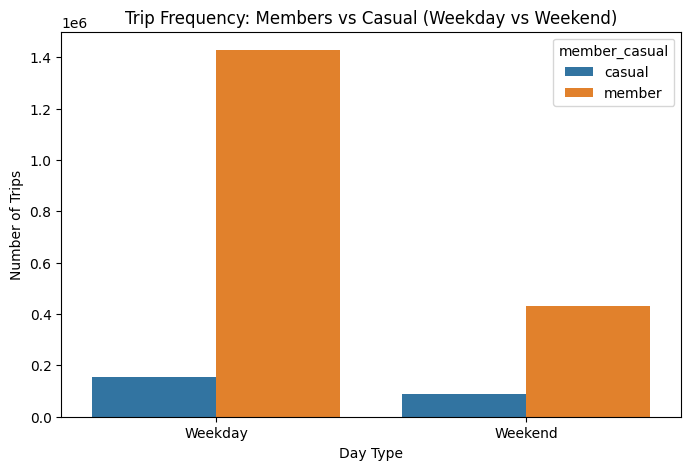

In [12]:
#Plot Trip Frequency
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=trip_counts,
    x="day_type",
    y="trip_count",
    hue="member_casual"
)

plt.title("Trip Frequency: Members vs Casual (Weekday vs Weekend)")
plt.xlabel("Day Type")
plt.ylabel("Number of Trips")

plt.show()

### Insight:
Members ride significantly more during weekdays, indicating commuting behavior.  
Casual riders increase usage on weekends, suggesting recreational use.

In [13]:
#Trip Duration Analysis
trip_duration = get_summary_table(df)
trip_duration

,day_type,member_casual,trip_count,avg_duration
0,Weekday,casual,156277,12.59
1,Weekday,member,1427646,9.73
2,Weekend,casual,86670,14.84
3,Weekend,member,429693,10.32


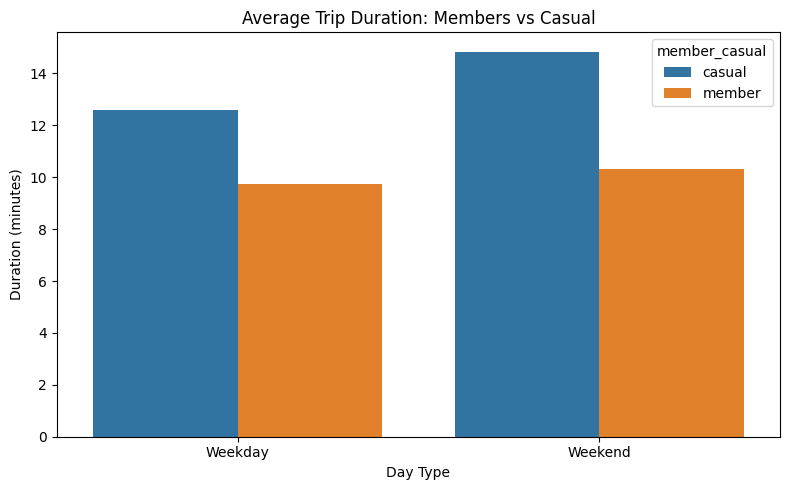

In [14]:
#Plot: Trip Duration
plt.figure(figsize=(8,5))

sns.barplot(
    data=trip_duration,
    x="day_type",
    y="avg_duration",
    hue="member_casual"
)

plt.title("Average Trip Duration: Members vs Casual")
plt.xlabel("Day Type")
plt.ylabel("Duration (minutes)")

plt.tight_layout()
plt.show()

### Insight:
Casual riders take longer trips on average, while members take shorter, more consistent trips.  
This supports the idea that members use Citi Bike for transportation rather than leisure.

In [15]:
#Hourly Usage Pattern
hourly = df.groupby(["hour", "member_casual"]).size().reset_index(name="trip_count")
hourly

,hour,member_casual,trip_count
0,0,casual,4396
1,0,member,19430
2,1,casual,2766
3,1,member,11005
4,2,casual,1787
5,2,member,6859
6,3,casual,1162
7,3,member,4770
8,4,casual,1134
9,4,member,5129


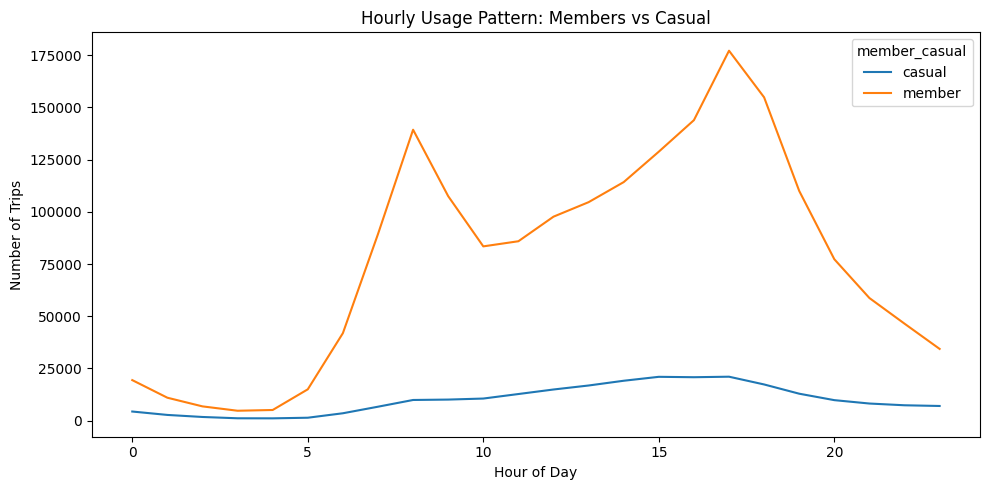

In [16]:
#Plot Hourly Usage
plt.figure(figsize=(10,5))

sns.lineplot(
    data=hourly,
    x="hour",
    y="trip_count",
    hue="member_casual"
)

plt.title("Hourly Usage Pattern: Members vs Casual")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

### Insight:
Members show clear peaks during morning and evening commute hours.  
Casual riders peak midday, aligning with tourism and leisure activities.

In [17]:
#Top Start Stations by Day
top_stations = df.groupby(["day_type", "start_station_name"]).size().reset_index(name="trip_count")

#Get Top 10 per group
top_weekday = top_stations[top_stations["day_type"] == "Weekday"].nlargest(10, "trip_count")

top_weekend = top_stations[top_stations["day_type"] == "Weekend"].nlargest(10, "trip_count")

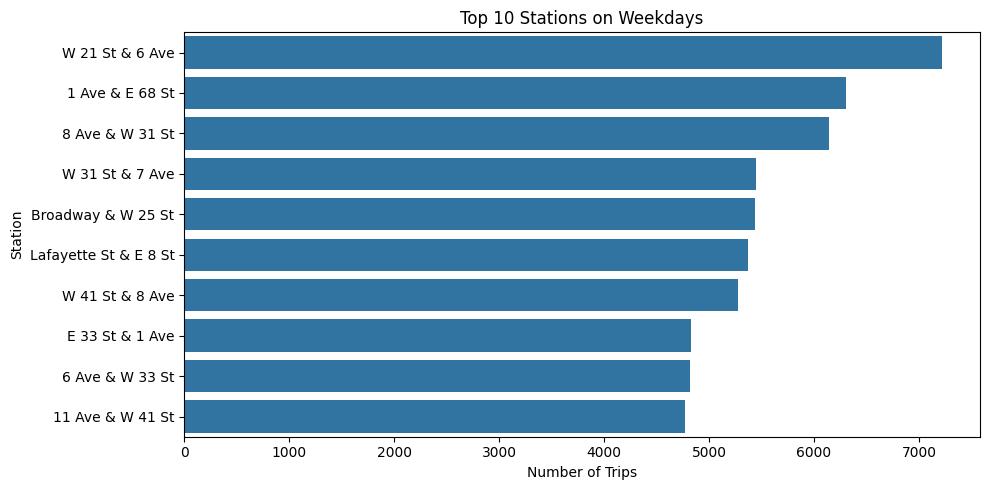

In [18]:
#Plot Weekday Top Stations


plt.figure(figsize=(10,5))

sns.barplot(
    data=top_weekday,
    y="start_station_name",
    x="trip_count"
)

plt.title("Top 10 Stations on Weekdays")
plt.xlabel("Number of Trips")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

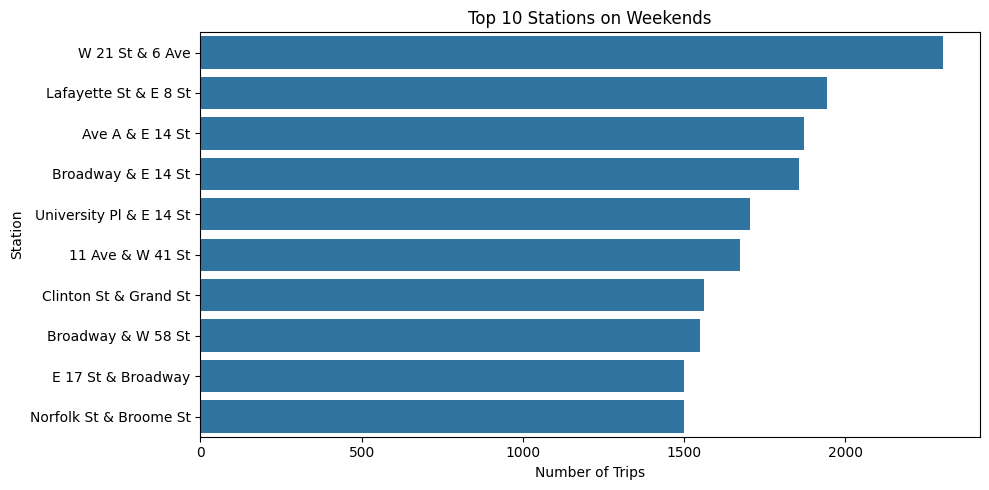

In [19]:
#Plot Weekend Top Stations
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_weekend,
    y="start_station_name",
    x="trip_count"
)

plt.title("Top 10 Stations on Weekends")
plt.xlabel("Number of Trips")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

### Insight:
Weekday trips are concentrated near business districts and transit hubs.  
Weekend trips shift toward parks and recreational areas.

 Station Analysis: Member vs Casual

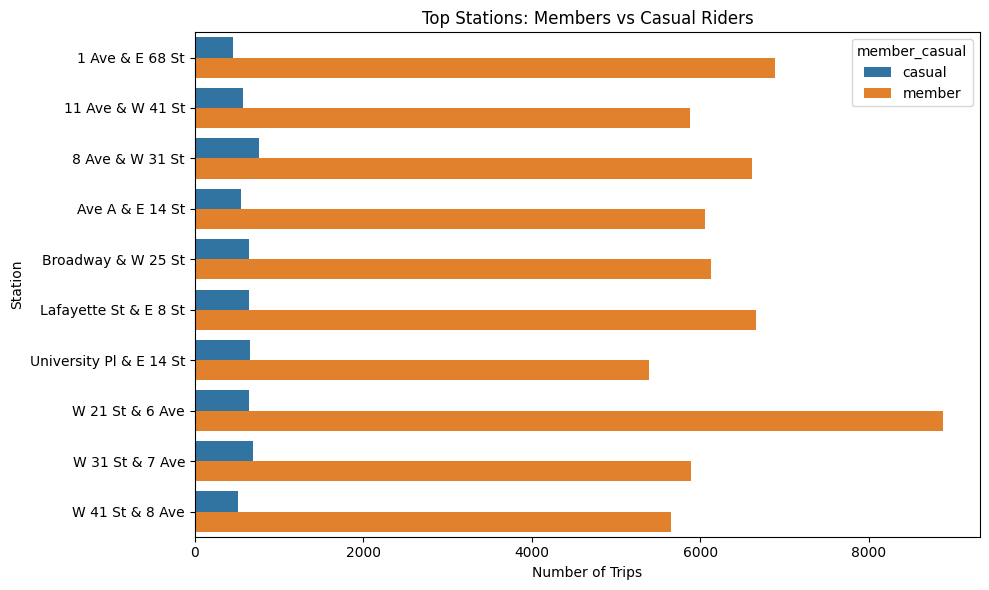

In [20]:
station_user = df.groupby(
    ["start_station_name", "member_casual"]
).size().reset_index(name="trip_count")

# Top 10 busiest stations overall
top10 = station_user.groupby("start_station_name")["trip_count"].sum().nlargest(10).index

filtered = station_user[station_user["start_station_name"].isin(top10)]

plt.figure(figsize=(10,6))

sns.barplot(
    data=filtered,
    y="start_station_name",
    x="trip_count",
    hue="member_casual"
)

plt.title("Top Stations: Members vs Casual Riders")
plt.xlabel("Number of Trips")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

### Insight:
Some stations are heavily dominated by members (commuter hubs),  
while others attract more casual riders (tourist hotspots).

In [21]:
summary_table = get_summary_table(df)
summary_table

,day_type,member_casual,trip_count,avg_duration
0,Weekday,casual,156277,12.59
1,Weekday,member,1427646,9.73
2,Weekend,casual,86670,14.84
3,Weekend,member,429693,10.32


##  Conclusion

This analysis identifies two distinct Citi Bike user segments:

- **Members (Subscribers)** behave as commuters:
  - Higher usage on weekdays
  - Short, frequent trips
  - Peak activity during commute hours

- **Casual Riders** behave as leisure users:
  - Increased weekend activity
  - Longer trip durations
  - Midday usage patterns

 **Key Takeaway:**
Citi Bike serves both transportation and recreational needs, with clear differences in when, how, and where each group rides.

 **Business Impact:**
- Improve commuter incentives for members
- Design targeted promotions for casual riders
- Optimize station placement based on weekday vs weekend demand